# Step 3: Exploratory Data Analysis (EDA)
## Singapore LNG & Gas Market Analytics

**Notebook:** 03_eda.ipynb  
**Data source:** data/clean/master_raw.csv  
**Objective:** Understand distributions, trends, correlations and seasonalpatterns across all six variables before modelling.

### Variables
| Column | Description | Unit |
|---|---|---|
| `jkm_price` | JKM Asia LNG spot price | USD/MMBtu |
| `ttf_price` | TTF Europe gas hub price | USD/MMBtu |
| `henry_price` | Henry Hub US gas price | USD/MMBtu |
| `usep_price` | Singapore USEP electricity price | SGD/MWh |
| `lng_import_tonnes` | Singapore LNG imports | Metric tonnes |
| `png_import_tonnes` | Singapore pipeline gas imports | Metric tonnes |
| `total_gas_tonnes` | Total gas supply | Metric tonnes |
| `lng_share` | LNG as share of total gas supply | 0–1 ratio |

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
master = pd.read_csv(
    'data/clean/master_raw.csv',
    index_col='date',
    parse_dates=True
)

print("Shape:", master.shape)
print("Date range:", master.index.min().date(), "→", master.index.max().date())
print("\nColumns:", master.columns.tolist())
print("\nMissing values:")
print(master.isnull().sum())
print("\nFirst 10 rows:")
print(master.head(10))

Shape: (256, 10)
Date range: 2005-01-01 → 2026-04-01

Columns: ['jkm_price', 'henry_price', 'ttf_price', 'USEP', 'lng_import_tonnes', 'png_import_tonnes', 'lng_outlier_flag', 'total_gas_tonnes', 'lng_share', 'png_share']

Missing values:
jkm_price             0
henry_price           0
ttf_price             0
USEP                  0
lng_import_tonnes    73
png_import_tonnes    73
lng_outlier_flag     73
total_gas_tonnes     73
lng_share            73
png_share            73
dtype: int64

First 10 rows:
            jkm_price  henry_price  ttf_price   USEP  lng_import_tonnes  \
date                                                                      
2005-01-01       5.82     6.152000       5.06   78.6                NaN   
2005-02-01       6.10     6.138421       5.06   83.6                NaN   
2005-03-01       6.46     6.955455       5.06   97.7                NaN   
2005-04-01       7.04     7.175714       5.51   99.8                NaN   
2005-05-01       7.22     6.473810       5.

In [3]:
print("\nLast 10 rows:")
print(master.tail(10))


Last 10 rows:
            jkm_price  henry_price  ttf_price   USEP  lng_import_tonnes  \
date                                                                      
2025-07-01     12.261     3.310000  11.470646  121.6           558070.0   
2025-08-01     11.521     2.893810  10.975232  103.6           487635.0   
2025-09-01     11.277     3.015000  11.003000  106.5           519915.0   
2025-10-01     10.842     3.353478  10.897000  102.0           577725.0   
2025-11-01     11.067     4.463500  10.355000  139.7           465497.0   
2025-12-01      9.910     4.431364   9.460000   95.1           639810.0   
2026-01-01     10.435     4.144545  11.987000  118.6           274173.0   
2026-02-01     10.752     3.147500  11.190000  132.9           412006.0   
2026-03-01     20.812     3.035909  17.670000  160.4           499947.0   
2026-04-01     20.812     3.035909  17.670000  194.5                NaN   

            png_import_tonnes  lng_outlier_flag  total_gas_tonnes  lng_share  \
date

In [4]:
# Remove Apr 2026 from master — incomplete month, all columns
master = master[master.index != pd.Timestamp('2026-04-01')]

print(f"Last date in master: {master.index.max().date()}")   # Should show 2026-03-01
print(f"Shape: {master.shape}")

Last date in master: 2026-03-01
Shape: (255, 10)


## 3.1 Descriptive Statistics

In [5]:
# Summary statistics for all numeric columns
desc = master.describe().round(2)
print(desc.to_string())

       jkm_price  henry_price  ttf_price    USEP  lng_import_tonnes  png_import_tonnes  lng_outlier_flag  total_gas_tonnes  lng_share  png_share
count     255.00       255.00     255.00  255.00             183.00             183.00            183.00            183.00     183.00     183.00
mean       12.14         4.25      10.46  148.74          258340.19          545928.45              0.01         804268.64       0.29       0.71
std         7.15         2.23       7.90   75.71          189452.88           88687.03              0.07         147020.57       0.19       0.19
min         2.03         1.70       1.46   43.60               0.00          357518.00              0.00         476572.00       0.00       0.22
25%         7.76         2.75       6.47   98.35          134121.50          475762.50              0.00         734804.00       0.18       0.57
50%        10.04         3.49       8.65  132.80          255319.00          559643.00              0.00         815419.00       0

In [6]:
# Skewness and kurtosis 
print("=== Skewness (>1 or <-1 = significantly skewed) ===")
print(master.skew().round(3))

print("\n=== Kurtosis (>3 = heavy tails) ===")
print(master.kurtosis().round(3))

=== Skewness (>1 or <-1 = significantly skewed) ===
jkm_price             2.287
henry_price           1.675
ttf_price             3.843
USEP                  1.834
lng_import_tonnes     0.870
png_import_tonnes    -0.108
lng_outlier_flag     13.528
total_gas_tonnes      0.747
lng_share            -0.169
png_share             0.169
dtype: float64

=== Kurtosis (>3 = heavy tails) ===
jkm_price              7.821
henry_price            3.063
ttf_price             20.064
USEP                   5.049
lng_import_tonnes      3.459
png_import_tonnes     -0.483
lng_outlier_flag     183.000
total_gas_tonnes       5.775
lng_share             -0.861
png_share             -0.861
dtype: float64


## 3.2 Time Series Plots — All Variables

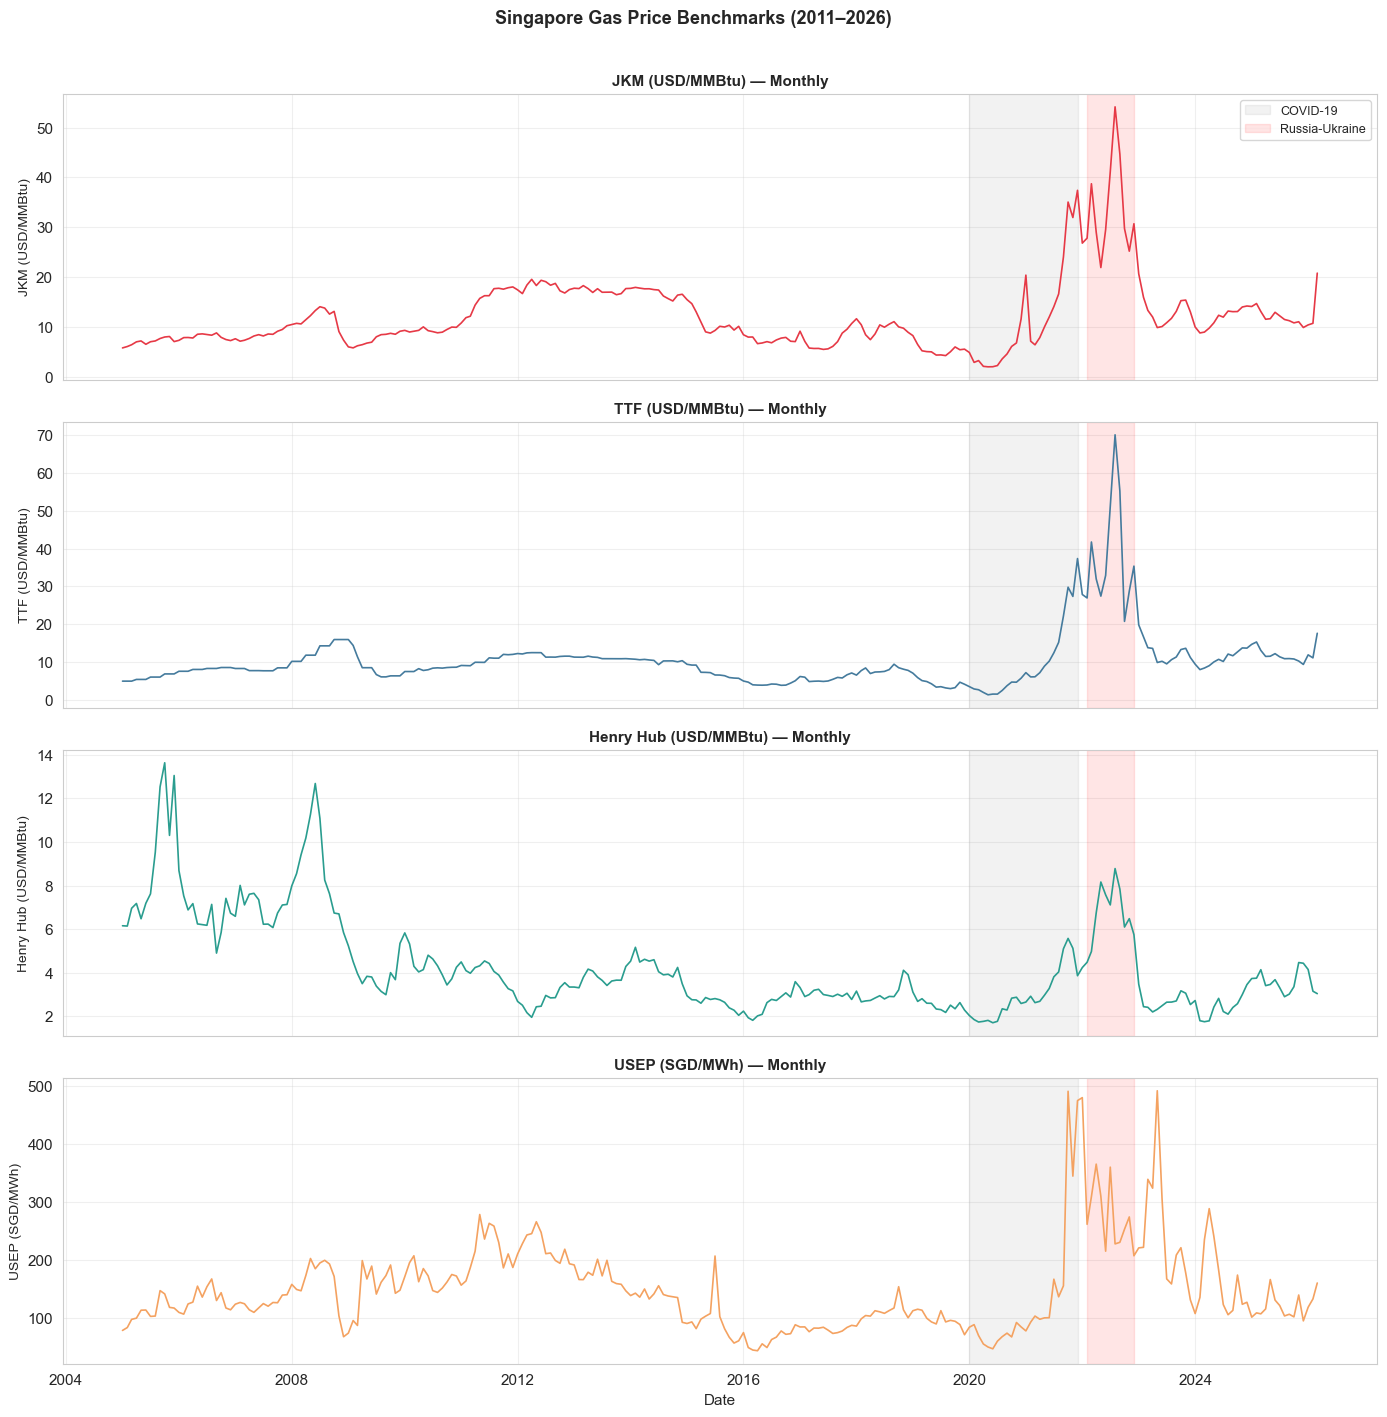

✅ Saved: charts/03_price_timeseries.png


In [7]:
import os 

#Price series over time

price_cols = ['jkm_price', 'ttf_price', 'henry_price', 'USEP']
price_labels = ['JKM (USD/MMBtu)', 'TTF (USD/MMBtu)',
                'Henry Hub (USD/MMBtu)', 'USEP (SGD/MWh)']
colors = ['#e63946', '#457b9d', '#2a9d8f', '#f4a261']

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, col, label, color in zip(axes, price_cols, price_labels, colors):
    ax.plot(master.index, master[col], color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} — Monthly', fontsize=11, fontweight='bold')

    # Shade COVID period
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-01'),
               alpha=0.1, color='grey', label='COVID-19')
    # Shade Russia-Ukraine war
    ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-01'),
               alpha=0.1, color='red', label='Russia-Ukraine')

axes[0].legend(fontsize=9)
axes[-1].set_xlabel('Date')
plt.suptitle('Singapore Gas Price Benchmarks (2011–2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

# Create the charts directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.savefig('charts/03_price_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/03_price_timeseries.png")

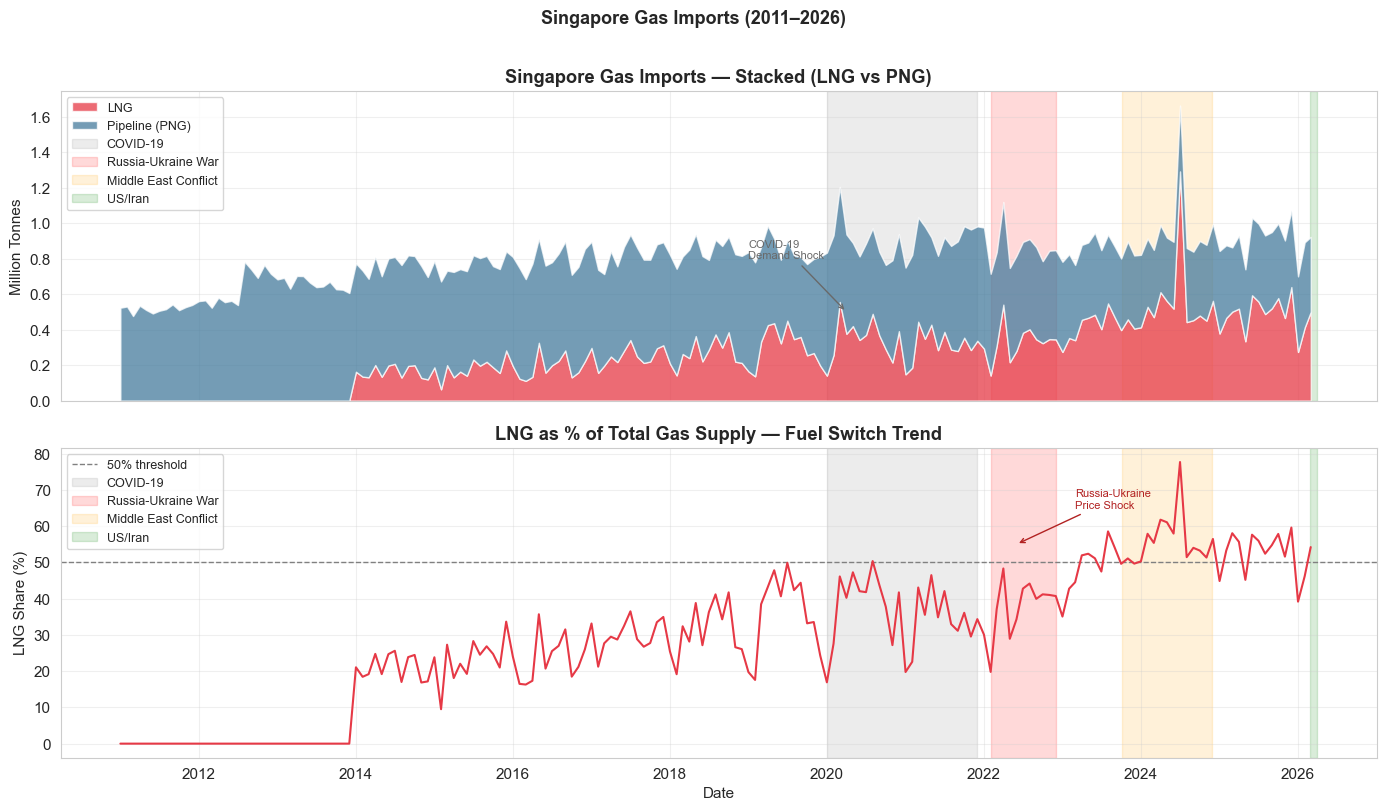

✅ Saved: charts/03_gas_imports_fuelswitch.png


In [8]:
# Gas Import Volumes Over Time

os.makedirs('charts', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Event period definitions ──────────────────────────────────────────────────
events = [
    (pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-01'), 'grey',  0.15, 'COVID-19'),
    (pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-01'), 'red',   0.15, 'Russia-Ukraine War'),
    (pd.Timestamp('2023-10-07'), pd.Timestamp('2024-11-27'), 'orange',0.15, 'Middle East Conflict'),
    (pd.Timestamp('2026-02-28'), pd.Timestamp('2026-03-31'), 'green',0.15, 'US/Iran')
]

# ── Plot 1: Stacked area — LNG vs PNG ────────────────────────────────────────
axes[0].stackplot(
    master.index,
    master['lng_import_tonnes'] / 1e6,
    master['png_import_tonnes'] / 1e6,
    labels=['LNG', 'Pipeline (PNG)'],
    colors=['#e63946', '#457b9d'],
    alpha=0.75
)
for start, end, color, alpha, label in events:
    axes[0].axvspan(start, end, color=color, alpha=alpha, label=label, zorder=0)
axes[0].set_ylabel('Million Tonnes')
axes[0].set_title('Singapore Gas Imports — Stacked (LNG vs PNG)', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)

# ── Plot 2: LNG share line ────────────────────────────────────────────────────
axes[1].plot(master.index, master['lng_share'] * 100,
             color='#e63946', linewidth=1.5, zorder=3)
axes[1].axhline(50, color='grey', linestyle='--', linewidth=1,
                label='50% threshold', zorder=2)
for start, end, color, alpha, label in events:
    axes[1].axvspan(start, end, color=color, alpha=alpha, label=label, zorder=0)
axes[1].set_ylabel('LNG Share (%)')
axes[1].set_title('LNG as % of Total Gas Supply — Fuel Switch Trend', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=9)

# ── Annotations ───────────────────────────────────────────────────────────────
axes[0].annotate('COVID-19\nDemand Shock',
                 xy=(pd.Timestamp('2020-04-01'), 0.5),
                 xytext=(pd.Timestamp('2019-01-01'), 0.8),
                 fontsize=8, color='dimgrey',
                 arrowprops=dict(arrowstyle='->', color='dimgrey'))

axes[1].annotate('Russia-Ukraine\nPrice Shock',
                 xy=(pd.Timestamp('2022-06-01'), 55),
                 xytext=(pd.Timestamp('2023-03-01'), 65),
                 fontsize=8, color='firebrick',
                 arrowprops=dict(arrowstyle='->', color='firebrick'))

plt.suptitle('Singapore Gas Imports (2011–2026)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/03_gas_imports_fuelswitch.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/03_gas_imports_fuelswitch.png")

## 3.3 Distribution Analysis

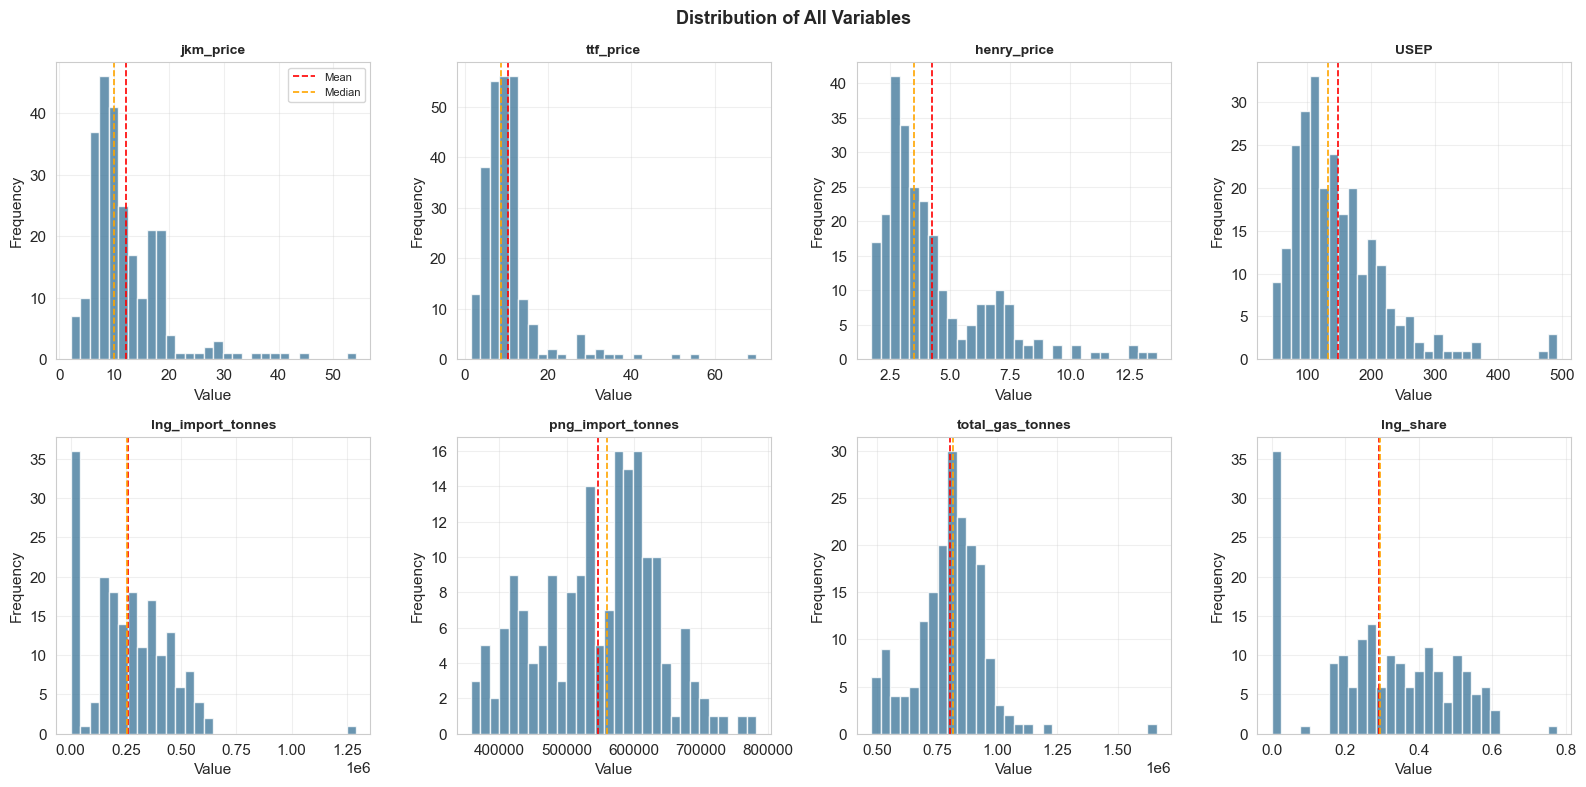

In [9]:
# Distribution Plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = ['jkm_price', 'ttf_price', 'henry_price', 'USEP',
        'lng_import_tonnes', 'png_import_tonnes', 'total_gas_tonnes', 'lng_share']

for ax, col in zip(axes.flatten(), cols):
    data = master[col].dropna()
    ax.hist(data, bins=30, color='#457b9d', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label='Median')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[0][0].legend(fontsize=8)
plt.suptitle('Distribution of All Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Correlation Analysis

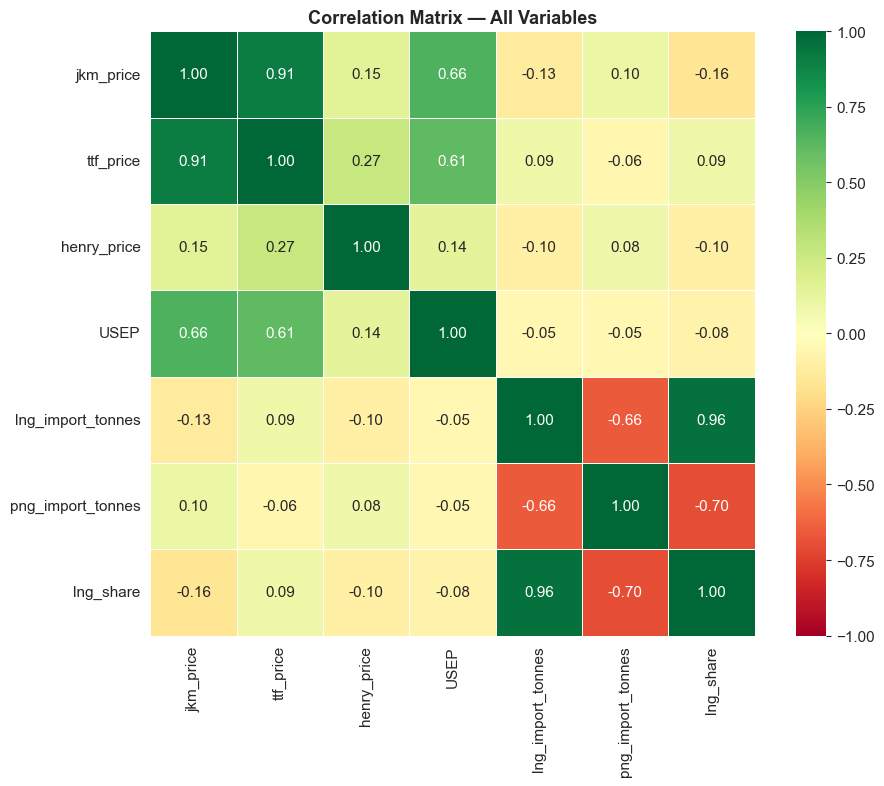


Top correlations with JKM price:
jkm_price            1.00
ttf_price            0.91
USEP                 0.66
henry_price          0.15
png_import_tonnes    0.10
lng_import_tonnes   -0.13
lng_share           -0.16


In [10]:
# Correlation Heatmap

corr_cols = ['jkm_price', 'ttf_price', 'henry_price', 'USEP',
             'lng_import_tonnes', 'png_import_tonnes', 'lng_share']

corr = master[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # Upper triangle only

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True
)
ax.set_title('Correlation Matrix — All Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with JKM price:")
print(corr['jkm_price'].sort_values(ascending=False).to_string())

## 3.5 Seasonal Analysis

/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_7394/778413472.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_data, labels=month_names, patch_artist=True)
/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_7394/778413472.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_data, labels=month_names, patch_artist=True)
/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_7394/778413472.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_data, labels=month_names, patch_artist=True)
/var/folders/0x/mscvgzz97h74r2hyx017c

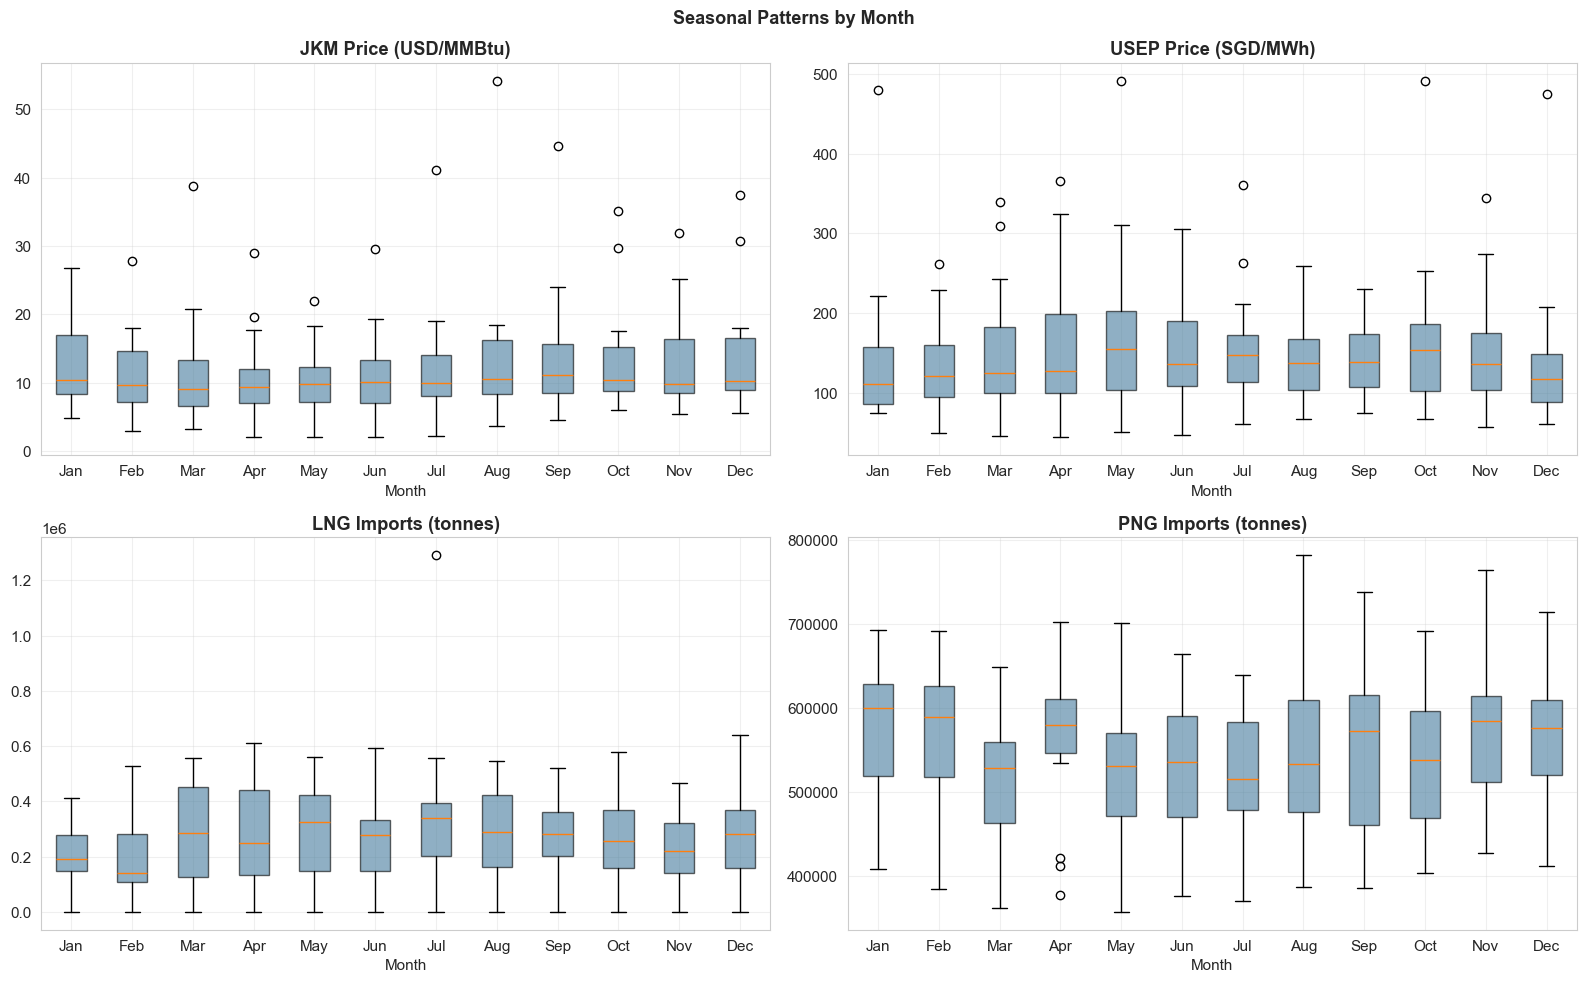

In [11]:
#Seasonal Boxplots

master['month'] = master.index.month
master['year']  = master.index.year
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_pairs = [
    ('jkm_price',           'JKM Price (USD/MMBtu)',        axes[0][0]),
    ('USEP',          'USEP Price (SGD/MWh)',          axes[0][1]),
    ('lng_import_tonnes',   'LNG Imports (tonnes)',          axes[1][0]),
    ('png_import_tonnes',   'PNG Imports (tonnes)',          axes[1][1]),
]

for col, title, ax in plot_pairs:
    monthly_data = [master[master['month'] == m][col].dropna().values
                    for m in range(1, 13)]
    bp = ax.boxplot(monthly_data, labels=month_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#457b9d')
        patch.set_alpha(0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Month')

plt.suptitle('Seasonal Patterns by Month', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_seasonal_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

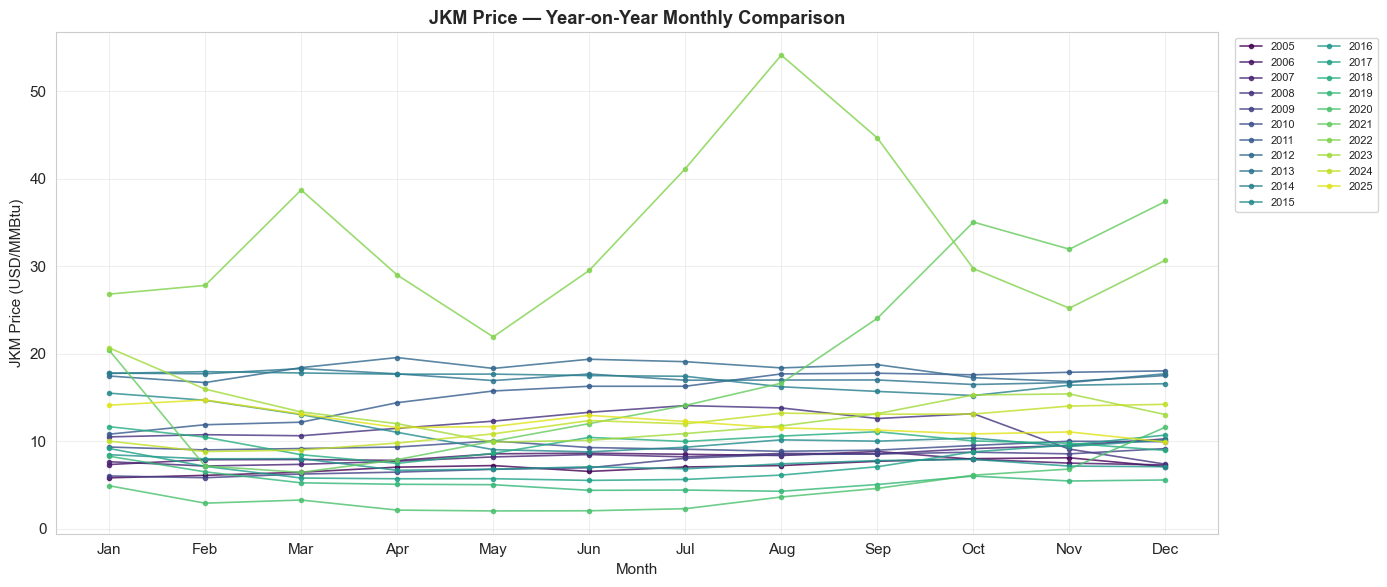

In [12]:
# Year-on-Year Comparison (JKM)

fig, ax = plt.subplots(figsize=(14, 6))

years = sorted(master['year'].unique())
cmap  = plt.cm.viridis(np.linspace(0, 1, len(years)))

for year, color in zip(years, cmap):
    yr_data = master[master['year'] == year]['jkm_price']
    if len(yr_data) >= 6:
        ax.plot(yr_data.index.month, yr_data.values,
                marker='o', markersize=3, linewidth=1.2,
                color=color, label=str(year), alpha=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('JKM Price (USD/MMBtu)')
ax.set_title('JKM Price — Year-on-Year Monthly Comparison', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('charts/03_jkm_yoy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Price Spread Analysis

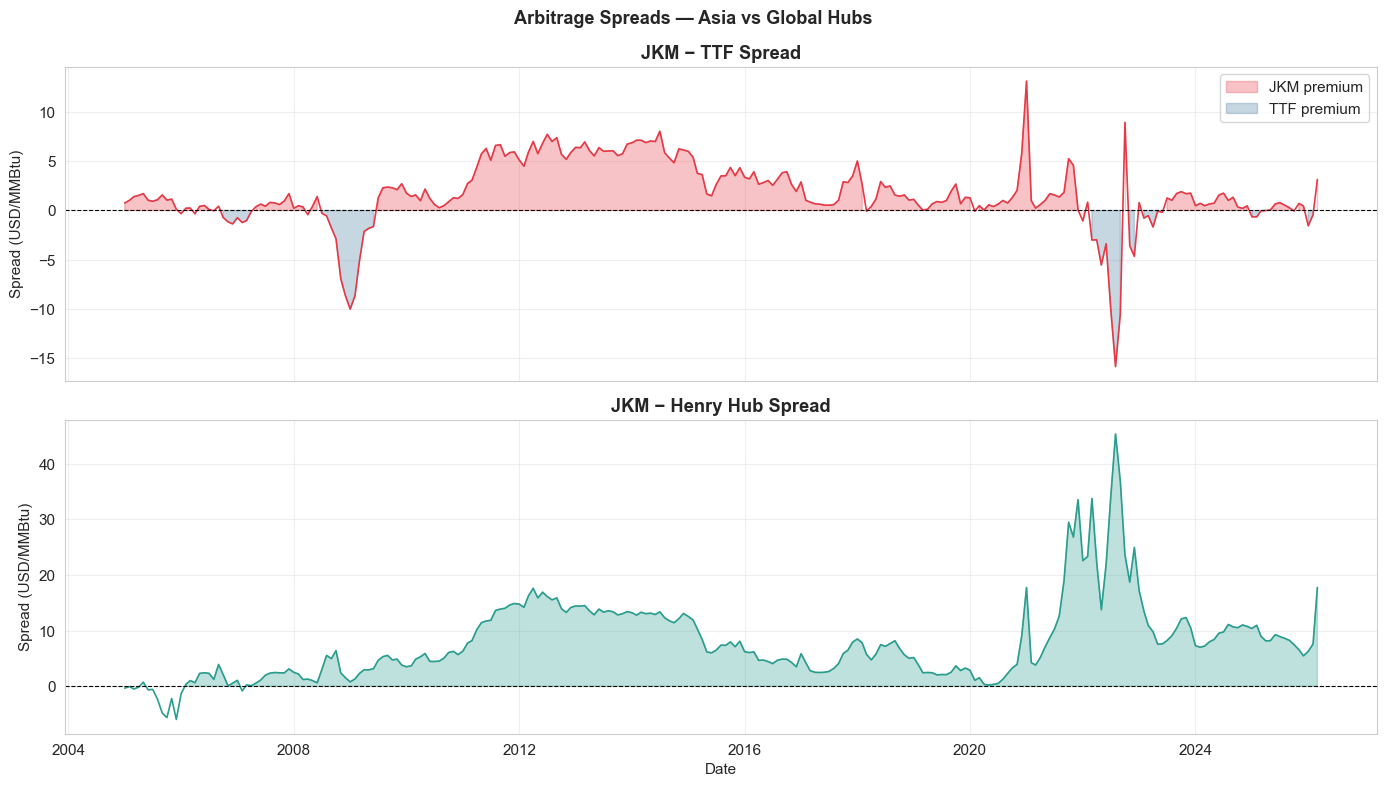

In [13]:
#JKM vs TTF and Henry Hub Spreads

master['jkm_ttf_spread']   = master['jkm_price'] - master['ttf_price']
master['jkm_henry_spread'] = master['jkm_price'] - master['henry_price']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(master.index, master['jkm_ttf_spread'],
             color='#e63946', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].fill_between(master.index, master['jkm_ttf_spread'], 0,
                     where=master['jkm_ttf_spread'] > 0,
                     alpha=0.3, color='#e63946', label='JKM premium')
axes[0].fill_between(master.index, master['jkm_ttf_spread'], 0,
                     where=master['jkm_ttf_spread'] < 0,
                     alpha=0.3, color='#457b9d', label='TTF premium')
axes[0].set_ylabel('Spread (USD/MMBtu)')
axes[0].set_title('JKM − TTF Spread', fontweight='bold')
axes[0].legend()

axes[1].plot(master.index, master['jkm_henry_spread'],
             color='#2a9d8f', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(master.index, master['jkm_henry_spread'], 0,
                     where=master['jkm_henry_spread'] > 0,
                     alpha=0.3, color='#2a9d8f')
axes[1].set_ylabel('Spread (USD/MMBtu)')
axes[1].set_title('JKM − Henry Hub Spread', fontweight='bold')
axes[1].set_xlabel('Date')

plt.suptitle('Arbitrage Spreads — Asia vs Global Hubs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_price_spreads.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Clean Up Temporary Columns and Save EDA-Ready Master
# Drop temporary helper columns added during EDA
master = master.drop(columns=['month', 'year',
                               'jkm_ttf_spread', 'jkm_henry_spread'],
                     errors='ignore')

# Save EDA-ready master (with outlier flag retained)
master.to_csv('data/clean/master_eda.csv', encoding='utf-8')

print("✅ Saved: data/clean/master_eda.csv")
print(f"   Shape: {master.shape}")
print(f"   Columns: {master.columns.tolist()}")

✅ Saved: data/clean/master_eda.csv
   Shape: (255, 10)
   Columns: ['jkm_price', 'henry_price', 'ttf_price', 'USEP', 'lng_import_tonnes', 'png_import_tonnes', 'lng_outlier_flag', 'total_gas_tonnes', 'lng_share', 'png_share']


## 3.7 EDA Summary & Key Findings

| Finding | Detail |
|---|---|
| **Fuel switch confirmed** | LNG share rose from ~0% (2013) to >50% by 2023 |
| **Price volatility** | JKM peaked ~$70/MMBtu in 2022 (Russia-Ukraine shock) |
| **Seasonal pattern** | LNG imports peak Jun–Aug (cooling demand driven) |
| **JKM–TTF correlation** | Strong positive — Asian and European markets linked |
| **Henry Hub decoupled** | Lower correlation — US domestic pricing still insulated |
| **Jul 2024 LNG spike** | Flagged as outlier — treat carefully in modelling |
| **PNG declining trend** | Indonesia pipeline contracts expiring — structural shift |

**Next step:** Step 4 — Feature Engineering, PCA and K-Means clustering